In [23]:
# u'' - 2u = 4x^2 - 2x - 4,  x in [0,1]
# Dirichlet: u(0)=0, u(1)=-1
# Neumann:  u(0)=0, u'(1)=-1 = g

# FDM Solution

# Grid setup
n = 3
h = 1.0 / n
x0, x1, x2, x3 = 0.0, h, 2*h, 1.0

# Source term
def f(x):
    return 4 * x**2 - 2 * x - 4

print("FDM: Dirichlet Conditions")
# Dirichlet BCs
u0 = 0.0
u3 = -1.0
c = -(2 + 2 * h**2) # FDM coefficient

# 2x2 system
a11 = c; a12 = 1.0
b1 = h**2 * f(x1) - u0
a21 = 1.0; a22 = c
b2 = h**2 * f(x2) - u3

print("\nSystem of Equations:")
print(f"[{a11:7.4f} {a12:7.4f}] [u1] = [{b1:7.4f}]")
print(f"[{a21:7.4f} {a22:7.4f}] [u2]   [{b2:7.4f}]\n")

# Solve 2x2
det = a11 * a22 - a12 * a21
u1 = (b1 * a22 - a12 * b2) / det
u2 = (a11 * b2 - b1 * a21) / det

print(f"u(0.000) = {u0:.4f}")
print(f"u(0.333) = {u1:.4f}")
print(f"u(0.667) = {u2:.4f}")
print(f"u(1.000) = {u3:.4f}")


print("\nFDM: Neumann Conditions")
# Neumann BCs
u0 = 0.0
g = -3.0

# 3x3 system
A = [
    [c, 1.0, 0.0],
    [1.0, c, 1.0],
    [1.0, -4.0, 3.0] # Derivative BC row
]
b = [
    h**2 * f(x1) - u0,
    h**2 * f(x2),
    2 * h * g
]

print("\nSystem of Equations:")
print(f"[{A[0][0]:7.4f} {A[0][1]:7.4f} {A[0][2]:7.4f}] [u1] = [{b[0]:7.4f}]")
print(f"[{A[1][0]:7.4f} {A[1][1]:7.4f} {A[1][2]:7.4f}] [u2]   [{b[1]:7.4f}]")
print(f"[{A[2][0]:7.4f} {A[2][1]:7.4f} {A[2][2]:7.4f}] [u3]   [{b[2]:7.4f}]\n")

# Solve 3x3 (Gauss)
M = [A[0] + [b[0]], A[1] + [b[1]], A[2] + [b[2]]]
rows = 3

# Forward elimination
for i in range(rows):
    pivot = M[i][i]
    for j in range(i, rows + 1):
        M[i][j] /= pivot
    for k in range(i + 1, rows):
        factor = M[k][i]
        for j in range(i, rows + 1):
            M[k][j] -= factor * M[i][j]

# Back substitution
sol = [0.0] * rows
for i in range(rows - 1, -1, -1):
    sol[i] = M[i][rows]
    for j in range(i + 1, rows):
        sol[i] -= M[i][j] * sol[j]

u1, u2, u3 = sol[0], sol[1], sol[2]

print(f"u(0.000) = {u0:.4f}")
print(f"u(0.333) = {u1:.4f}")
print(f"u(0.667) = {u2:.4f}")
print(f"u(1.000) = {u3:.4f}")



FDM: Dirichlet Conditions

System of Equations:
[-2.2222  1.0000] [u1] = [-0.4691]
[ 1.0000 -2.2222] [u2]   [ 0.6049]

u(0.000) = 0.0000
u(0.333) = 0.1111
u(0.667) = -0.2222
u(1.000) = -1.0000

FDM: Neumann Conditions

System of Equations:
[-2.2222  1.0000  0.0000] [u1] = [-0.4691]
[ 1.0000 -2.2222  1.0000] [u2]   [-0.3951]
[ 1.0000 -4.0000  3.0000] [u3]   [-2.0000]

u(0.000) = 0.0000
u(0.333) = 0.1111
u(0.667) = -0.2222
u(1.000) = -1.0000


In [24]:

# FEM
print("Finite Element Method (FEM)")
# Calculate elemental stiffness (k') and source (f) matrices
k_diff_e = [[1/h, -1/h], [-1/h, 1/h]]
k_react_e = [[2*h/3, h/3], [h/3, 2*h/3]]
k_prime_e = [[k_diff_e[i][j] + k_react_e[i][j] for j in range(2)] for i in range(2)]

# Elemental source vectors
f_elemental = {
    0: [56.0/81.0, 57.0/81.0],
    1: [55.0/81.0, 52.0/81.0],
    2: [42.0/81.0, 35.0/81.0]
}

# Step 2: Assemble global K and F matrices
num_nodes = n + 1
K_global = [[0.0] * num_nodes for _ in range(num_nodes)]
F_global = [0.0] * num_nodes

for i in range(n):
    # Assemble stiffness matrix
    K_global[i][i]     += k_prime_e[0][0]
    K_global[i][i+1]   += k_prime_e[0][1]
    K_global[i+1][i]   += k_prime_e[1][0]
    K_global[i+1][i+1] += k_prime_e[1][1]

    # Assemble source vector
    f_e = f_elemental[i]
    F_global[i]        += f_e[0]
    F_global[i+1]      += f_e[1]

#  FEM Solution

print("FEM: Dirichlet Conditions")
# Dirichlet BCs
u0 = 0.0
u3 = -1.0

# 2x2 system (reduce global system)
a11 = K_global[1][1]; a12 = K_global[1][2]
b1 = F_global[1] - K_global[1][0] * u0
a21 = K_global[2][1]; a22 = K_global[2][2]
b2 = F_global[2] - K_global[2][3] * u3

print("\nSystem of Equations:")
print(f"[{a11:7.4f} {a12:7.4f}] [u1] = [{b1:7.4f}]")
print(f"[{a21:7.4f} {a22:7.4f}] [u2]   [{b2:7.4f}]\n")

# Solve 2x2
det = a11 * a22 - a12 * a21
u1 = (b1 * a22 - a12 * b2) / det
u2 = (a11 * b2 - b1 * a21) / det

print(f"u(0.000) = {u0:.4f}")
print(f"u(0.333) = {u1:.4f}")
print(f"u(0.667) = {u2:.4f}")
print(f"u(1.000) = {u3:.4f}")


print("\nFEM: Neumann Conditions")
# Neumann BCs
u0 = 0.0
g = -3.0

# 3x3 system (reduce global system)
A = [
    [K_global[1][1], K_global[1][2], K_global[1][3]],
    [K_global[2][1], K_global[2][2], K_global[2][3]],
    [K_global[3][1], K_global[3][2], K_global[3][3]]
]
b = [
    F_global[1] - K_global[1][0] * u0,
    F_global[2],
    F_global[3] + g  # Add Neumann contribution
]

print("\nSystem of Equations:")
print(f"[{A[0][0]:7.4f} {A[0][1]:7.4f} {A[0][2]:7.4f}] [u1] = [{b[0]:7.4f}]")
print(f"[{A[1][0]:7.4f} {A[1][1]:7.4f} {A[1][2]:7.4f}] [u2]   [{b[1]:7.4f}]")
print(f"[{A[2][0]:7.4f} {A[2][1]:7.4f} {A[2][2]:7.4f}] [u3]   [{b[2]:7.4f}]\n")

# Solve 3x3 (Gauss)
# augmented matrix M for the solver
M = [A[0] + [b[0]], A[1] + [b[1]], A[2] + [b[2]]]
rows = 3

# Forward elimination
for i in range(rows):
    pivot = M[i][i]
    if abs(pivot) > 1e-9: # Avoid division by zero
        for j in range(i, rows + 1):
            M[i][j] /= pivot
    for k in range(rows):
        if i != k:
            factor = M[k][i]
            for j in range(i, rows + 1):
                M[k][j] -= factor * M[i][j]

# The solution is now in the last column of the transformed matrix M
u1, u2, u3 = M[0][rows], M[1][rows], M[2][rows]

print(f"u(0.000) = {u0:.4f}")
print(f"u(0.333) = {u1:.4f}")
print(f"u(0.667) = {u2:.4f}")
print(f"u(1.000) = {u3:.4f}")



Finite Element Method (FEM)
FEM: Dirichlet Conditions

System of Equations:
[ 6.4444 -2.8889] [u1] = [ 1.3827]
[-2.8889  6.4444] [u2]   [-1.7284]

u(0.000) = 0.0000
u(0.333) = 0.1181
u(0.667) = -0.2153
u(1.000) = -1.0000

FEM: Neumann Conditions

System of Equations:
[ 6.4444 -2.8889  0.0000] [u1] = [ 1.3827]
[-2.8889  6.4444 -2.8889] [u2]   [ 1.1605]
[ 0.0000 -2.8889  3.2222] [u3]   [-2.5679]

u(0.000) = 0.0000
u(0.333) = 0.1231
u(0.667) = -0.2039
u(1.000) = -0.9798


In [25]:
# antiderivative for integration
def F_antiderivative(x):
    return (4.0/3.0)*x**3 - x**2 - 4*x

print("Finite Volume Method (FVM)")

# dirichlet conditions
print("\nFVM Dirichlet Conditions")
u0 = 0.0
u3 = -1.0
c = -(2 + 2 * h**2)

# formulate 2x2 system
a11 = c
a12 = 1.0
# integrate source term
b1 = h * (F_antiderivative(x1 + h/2.0) - F_antiderivative(x1 - h/2.0)) - u0

a21 = 1.0
a22 = c
# integrate source term
b2 = h * (F_antiderivative(x2 + h/2.0) - F_antiderivative(x2 - h/2.0)) - u3

print("\nSystem of Equations:")
print(f"[{a11:7.4f} {a12:7.4f}] [u1] = [{b1:7.4f}]")
print(f"[{a21:7.4f} {a22:7.4f}] [u2]   [{b2:7.4f}]\n")

# solve 2x2 system
det = a11 * a22 - a12 * a21
u1_sol = (b1 * a22 - a12 * b2) / det
u2_sol = (a11 * b2 - b1 * a21) / det

print(f"u({x0:.3f}) = {u0:.4f}")
print(f"u({x1:.3f}) = {u1_sol:.4f}")
print(f"u({x2:.3f}) = {u2_sol:.4f}")
print(f"u({x3:.3f}) = {u3:.4f}")

# neumann conditions
print("\nFVM Neumann Conditions")
u0 = 0.0

# formulate 3x3 system
a11, a12, a13 = c, 1.0, 0.0
a21, a22, a23 = 1.0, c, 1.0
a31, a32, a33 = 0.0, 3.0, -10.0/3.0 # boundary equation

# integrate source terms
b1 = h * (F_antiderivative(x1 + h/2.0) - F_antiderivative(x1 - h/2.0))
b2 = h * (F_antiderivative(x2 + h/2.0) - F_antiderivative(x2 - h/2.0))
b3 = 8.0/3.0 # from boundary analysis

print("\nSystem of Equations:")
print(f"[{a11:7.4f} {a12:7.4f} {a13:7.4f}] [u1] = [{b1:7.4f}]")
print(f"[{a21:7.4f} {a22:7.4f} {a23:7.4f}] [u2]   [{b2:7.4f}]")
print(f"[{a31:7.4f} {a32:7.4f} {a33:7.4f}] [u3]   [{b3:7.4f}]\n")

# solve 3x3 system
detA = a11*(a22*a33 - a23*a32) - a12*(a21*a33 - a23*a31) + a13*(a21*a32 - a22*a31)
detA1 = b1*(a22*a33 - a23*a32) - a12*(b2*a33 - a23*b3) + a13*(b2*a32 - a22*b3)
detA2 = a11*(b2*a33 - a23*b3) - b1*(a21*a33 - a23*a31) + a13*(a21*b3 - b2*a31)
detA3 = a11*(a22*b3 - b2*a32) - a12*(a21*b3 - b2*a31) + b1*(a21*a32 - a22*a31)

u1_sol = detA1 / detA
u2_sol = detA2 / detA
u3_sol = detA3 / detA

print(f"u({x0:.3f}) = {u0:.4f}")
print(f"u({x1:.3f}) = {u1_sol:.4f}")
print(f"u({x2:.3f}) = {u2_sol:.4f}")
print(f"u({x3:.3f}) = {u3_sol:.4f}")

Finite Volume Method (FVM)

FVM Dirichlet Conditions

System of Equations:
[-2.2222  1.0000] [u1] = [-0.4650]
[ 1.0000 -2.2222] [u2]   [ 0.6091]

u(0.000) = 0.0000
u(0.333) = 0.1077
u(0.667) = -0.2256
u(1.000) = -1.0000

FVM Neumann Conditions

System of Equations:
[-2.2222  1.0000  0.0000] [u1] = [-0.4650]
[ 1.0000 -2.2222  1.0000] [u2]   [-0.3909]
[ 0.0000  3.0000 -3.3333] [u3]   [ 2.6667]

u(0.000) = 0.0000
u(0.333) = 0.1062
u(0.667) = -0.2291
u(1.000) = -1.0062


In [26]:
nodes = [0.0, h, 2*h, 1.0]

# Exact solution function
def exact_solution(x):
    return -2 * x**2 + x

print("Exact Solution Values")
print("\nNode | x Coordinate | Exact u(x)")

# Calculate and print the exact value at each node
for i, x_coord in enumerate(nodes):
    u_exact = exact_solution(x_coord)
    print(f"Node {i}: x = {x_coord:.4f}, Exact u = {u_exact:.4f}")


Exact Solution Values

Node | x Coordinate | Exact u(x)
Node 0: x = 0.0000, Exact u = 0.0000
Node 1: x = 0.3333, Exact u = 0.1111
Node 2: x = 0.6667, Exact u = -0.2222
Node 3: x = 1.0000, Exact u = -1.0000


Plot saved as dirichlet_comparison.png
Plot saved as neumann_comparison.png


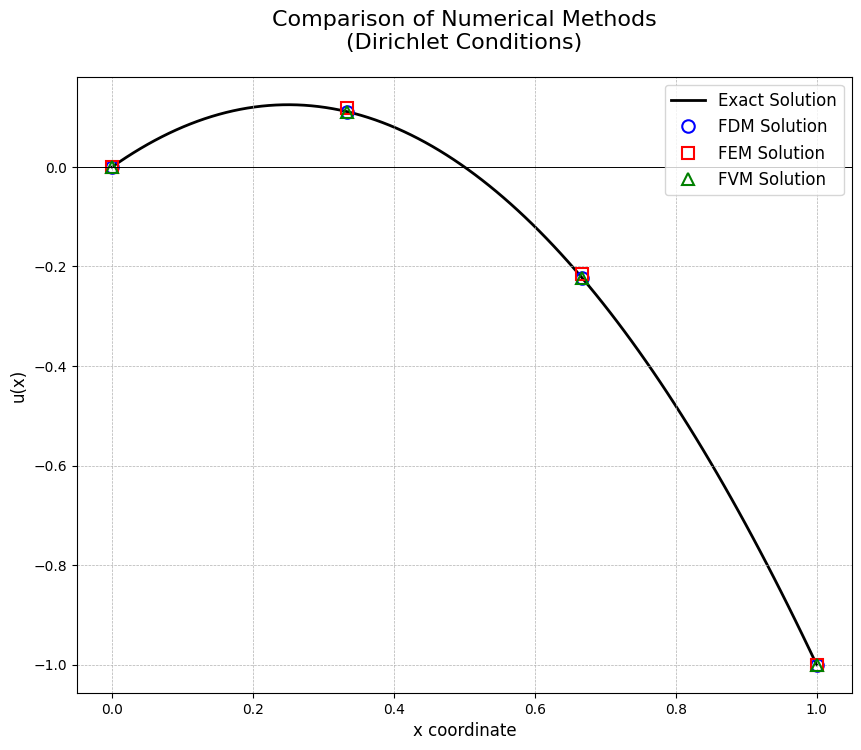

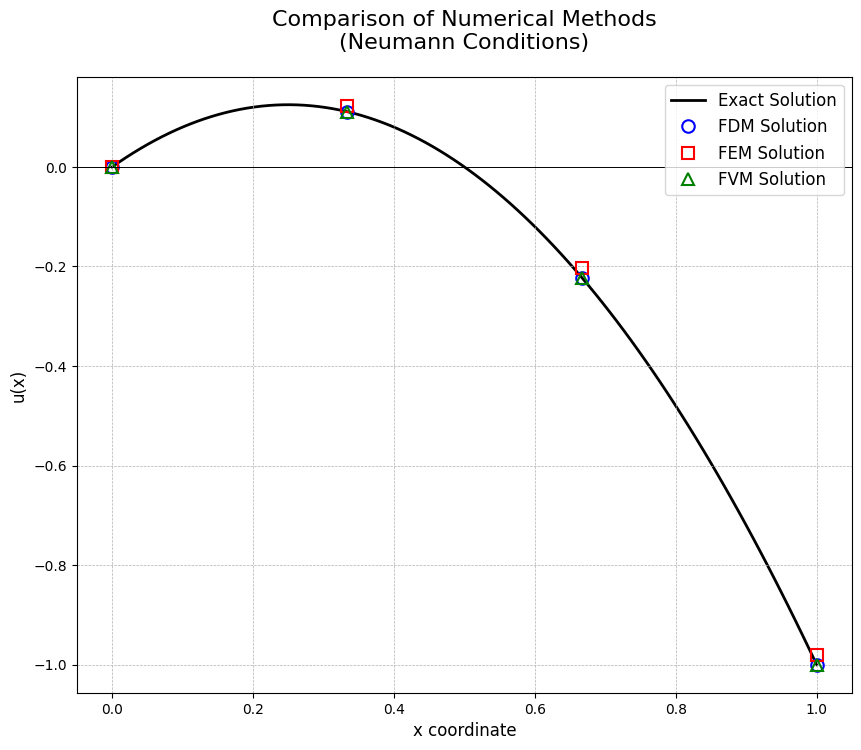

In [27]:
import numpy as np
import matplotlib.pyplot as plt


# Nodal points for the numerical solutions
x_nodes = np.array([0, 1/3, 2/3, 1])

# Data for Dirichlet Boundary Conditions
dirichlet_data = {
    'FDM': np.array([0, 0.1111, -0.2222, -1]),
    'FEM': np.array([0, 0.1181, -0.2153, -1]),
    'FVM': np.array([0, 0.1111, -0.2222, -1])
}

# Data for Neumann Boundary Conditions
neumann_data = {
    'FDM': np.array([0, 0.1111, -0.2222, -1]),
    'FEM': np.array([0, 0.1231, -0.2039, -0.9798]),
    'FVM': np.array([0, 0.1111, -0.2222, -1])
}

# Exact sol

# Generate a high-resolution curve for the exact solution for a smooth plot
x_exact = np.linspace(0, 1, 100)
u_exact = -2 * x_exact**2 + x_exact

# Plot

def create_plot(title, data, filename):
    """Creates and saves a plot comparing numerical solutions to the exact solution."""
    plt.figure(figsize=(10, 8)) # Made the plot taller

    # Plot the exact solution as a smooth line
    plt.plot(x_exact, u_exact, 'k-', label='Exact Solution', linewidth=2, zorder=1)

    # Plot the numerical solutions as distinct points
    plt.plot(x_nodes, data['FDM'], 'bo', label='FDM Solution', markersize=9, markerfacecolor='none', markeredgewidth=1.5, zorder=2)
    plt.plot(x_nodes, data['FEM'], 'rs', label='FEM Solution', markersize=9, markerfacecolor='none', markeredgewidth=1.5, zorder=2)
    plt.plot(x_nodes, data['FVM'], 'g^', label='FVM Solution', markersize=9, markerfacecolor='none', markeredgewidth=1.5, zorder=2)

    # Formatting the plot
    plt.title(title, fontsize=16, pad=20)
    plt.xlabel('x coordinate', fontsize=12)
    plt.ylabel('u(x)', fontsize=12)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend(fontsize=12, loc='upper right')
    plt.axhline(0, color='black', linewidth=0.7) # Add x-axis line

    # Save the plot to a file
    plt.savefig(filename)
    print(f"Plot saved as {filename}")

# --- Part 4: Generate Both Plots ---

# Create the plot for the Dirichlet case
create_plot('Comparison of Numerical Methods\n(Dirichlet Conditions)',
            dirichlet_data,
            'dirichlet_comparison.png')

# Create the plot for the Neumann case
create_plot('Comparison of Numerical Methods\n(Neumann Conditions)',
            neumann_data,
            'neumann_comparison.png')



Plot saved as dirichlet_spline_comparison.png
Plot saved as neumann_spline_comparison.png


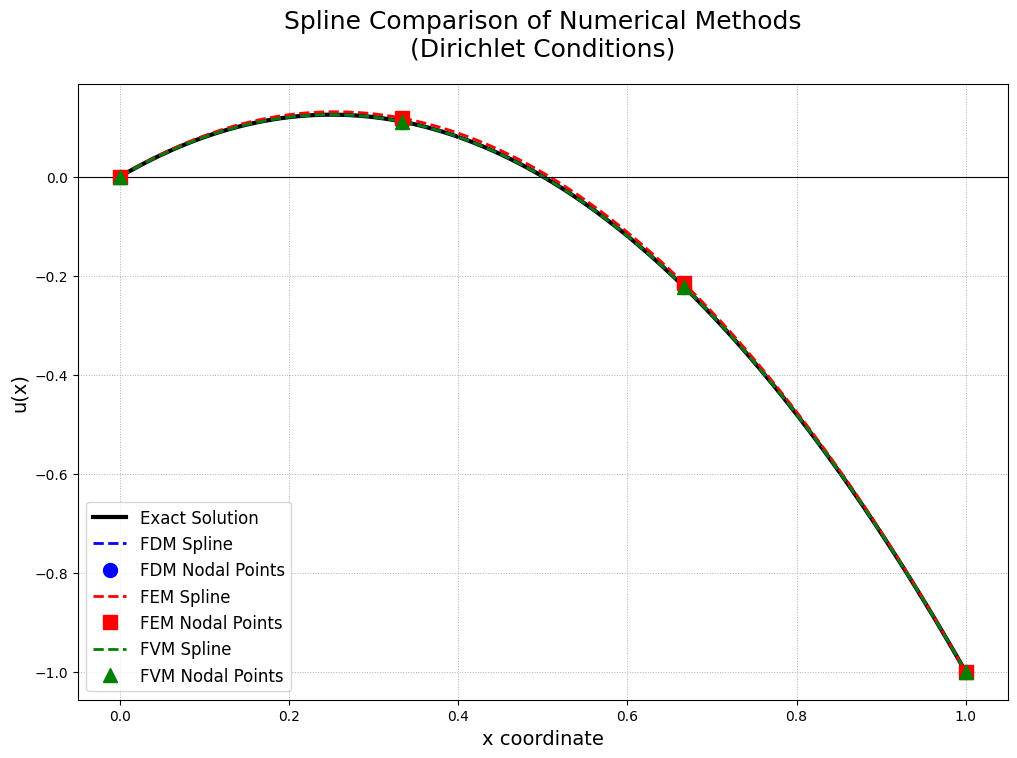

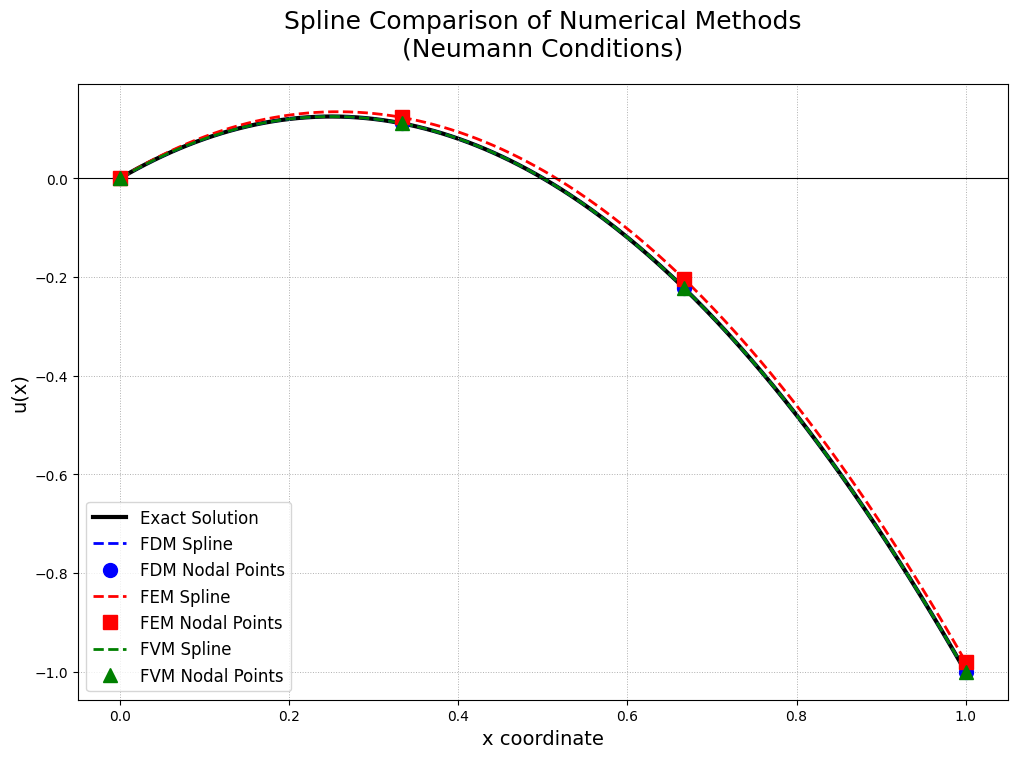

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# --- Part 1: Data Setup ---
# This data is from your 'error_analysis.xlsx' file.

# Nodal points for the numerical solutions
x_nodes = np.array([0, 1/3, 2/3, 1])

# Data for Dirichlet Boundary Conditions
dirichlet_data = {
    'FDM': np.array([0, 0.1111, -0.2222, -1]),
    'FEM': np.array([0, 0.1181, -0.2153, -1]),
    'FVM': np.array([0, 0.1111, -0.2222, -1])
}

# Data for Neumann Boundary Conditions
neumann_data = {
    'FDM': np.array([0, 0.1111, -0.2222, -1]),
    'FEM': np.array([0, 0.1231, -0.2039, -0.9798]),
    'FVM': np.array([0, 0.1111, -0.2222, -1])
}

# --- Part 2: Exact Solution ---

# Generate a high-resolution curve for the exact solution
x_exact = np.linspace(0, 1, 300)
u_exact = -2 * x_exact**2 + x_exact

# --- Part 3: Plotting Function ---

def create_spline_plot(title, data, filename):
    """Creates and saves a plot comparing spline-interpolated numerical solutions."""
    plt.figure(figsize=(12, 8))

    # Plot the exact solution as a solid black line
    plt.plot(x_exact, u_exact, 'k-', label='Exact Solution', linewidth=3, zorder=1)

    # Define colors and styles for the numerical methods
    styles = {
        'FDM': {'color': 'blue', 'style': '--', 'marker': 'o'},
        'FEM': {'color': 'red', 'style': '--', 'marker': 's'},
        'FVM': {'color': 'green', 'style': '--', 'marker': '^'}
    }

    # Generate and plot a spline for each numerical method
    for method, values in data.items():
        # Create a cubic spline that passes through the numerical solution points
        spline = CubicSpline(x_nodes, values)
        u_spline = spline(x_exact)

        # Plot the spline as a dashed line
        plt.plot(x_exact, u_spline,
                 color=styles[method]['color'],
                 linestyle=styles[method]['style'],
                 label=f'{method} Spline',
                 linewidth=2,
                 zorder=2)

        # Plot the original nodal points to show where the data comes from
        plt.plot(x_nodes, values,
                 color=styles[method]['color'],
                 marker=styles[method]['marker'],
                 linestyle='none',
                 markersize=10,
                 label=f'{method} Nodal Points',
                 zorder=3)

    # Formatting the plot
    plt.title(title, fontsize=18, pad=20)
    plt.xlabel('x coordinate', fontsize=14)
    plt.ylabel('u(x)', fontsize=14)
    plt.grid(True, which='both', linestyle=':', linewidth=0.7)
    plt.legend(fontsize=12)
    plt.axhline(0, color='black', linewidth=0.8)

    # Save the plot to a file
    plt.savefig(filename)
    print(f"Plot saved as {filename}")

# --- Part 4: Generate Both Plots ---

# Create the plot for the Dirichlet case
create_spline_plot('Spline Comparison of Numerical Methods\n(Dirichlet Conditions)',
                   dirichlet_data,
                   'dirichlet_spline_comparison.png')

# Create the plot for the Neumann case
create_spline_plot('Spline Comparison of Numerical Methods\n(Neumann Conditions)',
                   neumann_data,
                   'neumann_spline_comparison.png')
